<a href="https://colab.research.google.com/github/Neoseb92/Modulo-1-AI/blob/main/Notebook_Nox_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cargar ver datos


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

ruta = "contaminantes_2026(1).csv"
df = pd.read_csv(ruta, skiprows=9, encoding="utf-8")  # saltar la "portada"

vars_ = ["O3", "NO", "NO2", "NOX", "CO"]
mer = df[(df["id_station"] == "MER") & (df["id_parameter"].isin(vars_))]

# De apilado a una columna por contaminante
wide = mer.pivot_table(index="date", columns="id_parameter", values="valor")
wide.index = pd.to_datetime(wide.index)
wide = wide.sort_index().dropna()   # quita horas sin medición
print(wide.shape)
wide.head()

(4639, 5)


id_parameter,CO,NO,NO2,NOX,O3
date,,,,,
2026-01-01 00:00:00,1.05,7.0,41.0,47.0,7.0
2026-01-01 01:00:00,1.31,13.0,45.0,58.0,3.0
2026-01-01 02:00:00,1.63,27.0,48.0,76.0,3.0
2026-01-01 03:00:00,1.43,35.0,44.0,79.0,3.0
2026-01-01 04:00:00,1.22,12.0,44.0,56.0,4.0


Regresion


In [ ]:
X = sm.add_constant(wide[["NO", "NO2", "NOX", "CO"]])
y = wide["O3"]
modelo = sm.OLS(y, X).fit()
print(modelo.summary())   # R², coeficientes y p-values

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     394.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          4.76e-293
Time:                        03:26:46   Log-Likelihood:                -21912.
No. Observations:                4639   AIC:                         4.383e+04
Df Residuals:                    4634   BIC:                         4.387e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.3540      1.066     52.853      0.0

VIF


In [ ]:
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
    index=X.columns[1:]
)
print(vif)

NO     5063.595655
NO2     871.942799
NOX    8104.930265
CO        5.606601
dtype: float64


c) Residuos vs predichos + Breusch-Pagan


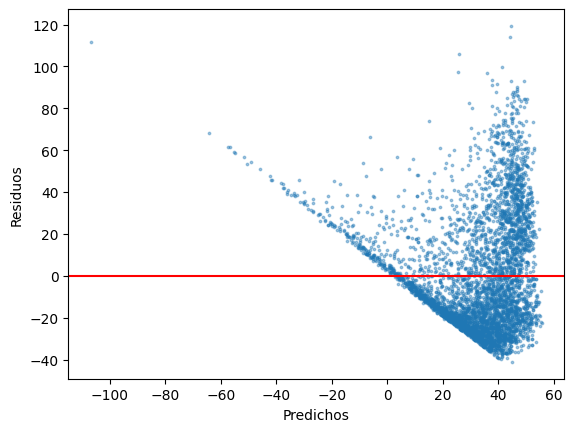

Breusch-Pagan p-value: 6.416020588467817e-19


In [ ]:
plt.scatter(modelo.fittedvalues, modelo.resid, s=3, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Predichos"); plt.ylabel("Residuos"); plt.show()

lm, lm_p, f, f_p = het_breuschpagan(modelo.resid, modelo.model.exog)
print("Breusch-Pagan p-value:", lm_p)

d) Residuos en el tiempo, por hora y Durbin-Watson

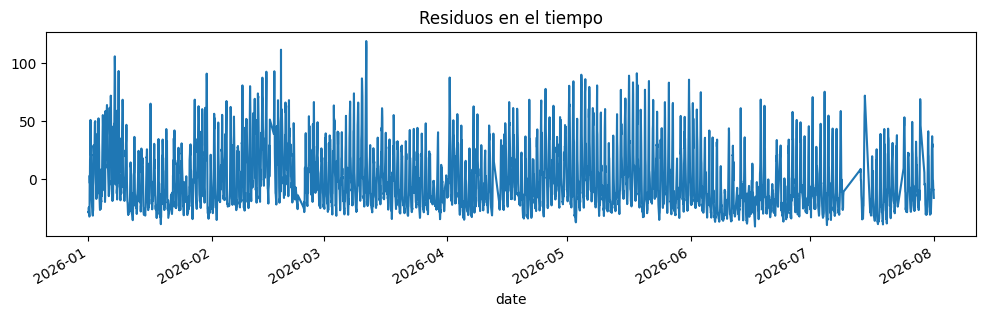

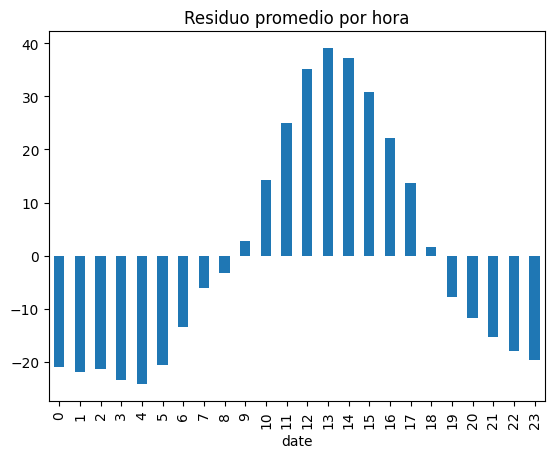

Durbin-Watson: 0.19394638503322317


In [ ]:
res = modelo.resid
res.plot(figsize=(12, 3), title="Residuos en el tiempo"); plt.show()

res.groupby(res.index.hour).mean().plot(kind="bar", title="Residuo promedio por hora")
plt.show()

print("Durbin-Watson:", durbin_watson(res))

QQ plot

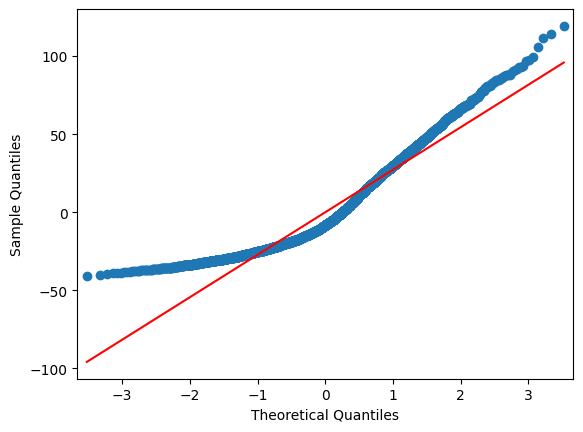

In [ ]:
sm.qqplot(res, line="s"); plt.show()

Prácticamente se rompen todos los supuestos del modelo lineal. Hay multicolinealidad severa, porque NOX es casi la suma de NO y NO2, así que no es posible variar uno manteniendo los otros fijos. Hay heterocedasticidad (Breusch-Pagan, p ≈ 6×10⁻¹⁹) y autocorrelación positiva fuerte en los residuos (Durbin-Watson = 0.19), con un patrón diario claro: el modelo sobreestima el ozono de noche y lo subestima a mediodía. Esto indica que falta una variable clave, la radiación solar u hora del día. Además, los residuos no son normales (asimetría positiva, Jarque-Bera p ≈ 0) y el R² es de solo 0.25. Por lo tanto, no le creemos al coeficiente del NO2 (0.69) ni a su p-value (0.386). El coeficiente no es interpretable por la colinealidad y está sesgado por la variable omitida. El p-value se basa en errores estándar que suponen residuos independientes y con varianza constante, y ninguna de las dos cosas se cumple. Para rescatarlo habría que quitar NOX, agregar la hora o la radiación y usar errores estándar robustos (HAC/Newey-West).